# Stage 0: where the poly3_total misfit lives

- Six `poly3_total` fits, no new sampling; CPU rebuild of each fit's own likelihood.
- Four yardsticks: chi2 map, prior rails, Lick-index recovery, Borghi+22 overlap.
- Output: tables here, `stage0_summary.csv`, four PNG figures beside this notebook.

In [1]:
import os, sys, json
os.environ.setdefault("JAX_PLATFORMS", "cpu")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import jax, jax.numpy as jnp
from astropy.table import Table

PROJECT_ROOT = Path(os.environ.get("CERIDWEN_PROJECT_ROOT", Path.cwd()))
while not (PROJECT_ROOT / "scripts" / "per_galaxy_diagnostics.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
import per_galaxy_diagnostics as pgd
from ceridwen.observation.stellar_indices import StellarIndices, LEGAC_DR2_STELLAR_INDEX_DEFINITIONS

OUT = PROJECT_ROOT / "results/fit-accuracy-knobs"
FITS = sorted((PROJECT_ROOT / "results/calibration-polynomial-dr2/poly3_total").glob("*-M*"))
pd.set_option("display.width", 200); pd.set_option("display.precision", 3)
[f.name for f in FITS]

['108989-M4_108989',
 '172669-M5_172669',
 '173928-M5_173928',
 '185653-M12_185653',
 '206545-M1_206545',
 '98104-M12_98104']

## Load fits and rebuild each likelihood

- `rebuild_model` now re-creates the marginalised order-3 calibration polynomial from the h5 attrs.
- `StellarIndices` rides along as an extra observation: predicted, never in the likelihood.

In [2]:
ssp = pgd.load_ssp()
galaxies, models = {}, {}
for folder in FITS:
    g = pgd.load_galaxy(folder)
    indices_obs = StellarIndices(
        definitions=LEGAC_DR2_STELLAR_INDEX_DEFINITIONS, resolution=g.spec["resolution"],
        smoothtype=g.spec["smoothtype"], res_convention=pgd.RES_CONVENTION,
        sigma_losvd=g.sigma_star_kms, name="stellar_indices",
    )
    model, likelihood, _ = pgd.rebuild_model(g, ssp, extra_observations=(indices_obs,))
    galaxies[g.spect_id] = g
    models[g.spect_id] = (model, likelihood, indices_obs)
TARGETS = list(galaxies)
# stored ln L is reproduced to a few 1e-4 (GPU float32 photometry vs CPU float64)
pd.DataFrame({t: {"z": g.z, "sigma_star": g.sigma_star_kms, "S/N": g.catalogue_sn,
                  "lnL rebuilt/stored - 1": pgd.likelihood_terms(*models[t][:2], pgd.theta_at(g, pgd.max_likelihood_index(g)))["lnl"]
                  / g.log_likelihoods[pgd.max_likelihood_index(g)] - 1}
              for t, g in galaxies.items()}).T

Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


/Users/liuhao/Downloads/Astro project/ceridwen/ceridwen/model/model.py:241: UserWarning: Spectrum 'spectrum': the SSP library resolution meets or exceeds the target resolution on 1% of pixels over [5249, 5484] AA (km/s); those pixels stay at LIBRARY resolution (no deconvolution is attempted).  The model cannot be as sharp as the data there — use a higher-resolution SSP grid.
  obs.setup_for_model(


Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


/Users/liuhao/Downloads/Astro project/ceridwen/ceridwen/model/model.py:241: UserWarning: Spectrum 'spectrum': the SSP library resolution meets or exceeds the target resolution on 3% of pixels over [5251, 5878] AA (km/s); those pixels stay at LIBRARY resolution (no deconvolution is attempted).  The model cannot be as sharp as the data there — use a higher-resolution SSP grid.
  obs.setup_for_model(


Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


/Users/liuhao/Downloads/Astro project/ceridwen/ceridwen/model/model.py:241: UserWarning: Spectrum 'spectrum': the SSP library resolution meets or exceeds the target resolution on 4% of pixels over [5248, 5945] AA (km/s); those pixels stay at LIBRARY resolution (no deconvolution is attempted).  The model cannot be as sharp as the data there — use a higher-resolution SSP grid.
  obs.setup_for_model(


,z,sigma_star,S/N,lnL rebuilt/stored - 1
M4_108989,0.828,310.3,21.3,-9.476e-08
M5_172669,0.604,223.8,105.0,1.606e-07
M5_173928,0.959,179.7,13.3,2.072e-08
M12_185653,0.678,173.8,21.5,-1.671e-07
M1_206545,0.728,210.0,31.4,-3.448e-07
M12_98104,0.981,223.5,6.6,-4.725e-08


## 1. Chi-squared map at the maximum-likelihood point

- Fitted f_calib absorbs misfit, so the raw column re-evaluates at fixed f_calib = 0.03.
- Line windows are +-1500 km/s around rest vacuum wavelengths; Hepsilon shares its window with Ca H.

In [3]:
C_KMS = 2.998e5
LINE_WINDOWS = {"[NeIII] 3869": 3869.86, "Hepsilon 3970": 3971.20, "Hdelta 4102": 4102.89, "Hgamma 4340": 4341.68}
BLUE_REST = (3800.0, 4300.0)
F_FIXED = 0.03

def window_fraction(g, chi, mask):
    rest = g.spec["wavelength"] / (1.0 + g.z)
    chi2 = np.where(mask, chi**2, 0.0)
    total = chi2.sum()
    out = {}
    for name, lam in LINE_WINDOWS.items():
        sel = np.abs(rest - lam) <= lam * 1500.0 / C_KMS
        out[name] = chi2[sel].sum() / total
    blue = (rest >= BLUE_REST[0]) & (rest <= BLUE_REST[1])
    out["blue 3800-4300"] = chi2[blue].sum() / total
    out["blue pixel share"] = (blue & mask).sum() / mask.sum()
    return out

rows, phot_pulls = [], {}
for t, g in galaxies.items():
    model, likelihood, _ = models[t]
    theta = pgd.theta_at(g, pgd.max_likelihood_index(g))
    fitted = pgd.likelihood_terms(model, likelihood, theta)
    theta_fixed = dict(theta); theta_fixed["log_f_calib"] = jnp.array([np.log(F_FIXED)])
    raw = pgd.likelihood_terms(model, likelihood, theta_fixed)
    mask = g.spec["mask"]
    chi_raw = raw["spectrum"]["chi"]
    irac = np.array(["irac" in f for f in g.phot["filters"]])
    pchi = fitted["photometry"]["chi"]
    phot_pulls[t] = dict(zip([f.split("_", 1)[-1] for f in g.phot["filters"]], pchi))
    row = {"target": t, "f_calib fit": fitted["f_calib"],
           "chi2/nu fitted f": fitted["spectrum"]["chi2"] / fitted["spectrum"]["ndof"],
           "chi2/nu f=0.03": raw["spectrum"]["chi2"] / raw["spectrum"]["ndof"],
           "chi2 spec f=0.03": raw["spectrum"]["chi2"],
           "|pull|>4 (f=0.03)": int((np.abs(chi_raw[mask]) > pgd.OUTLIER_PULL).sum()),
           "chi2 phot": fitted["photometry"]["chi2"],
           "IRAC share of phot chi2": (pchi[irac]**2).sum() / (pchi**2).sum()}
    row.update(window_fraction(g, chi_raw, mask))
    rows.append(row)
chi2_table = pd.DataFrame(rows).set_index("target")
chi2_table

,f_calib fit,chi2/nu fitted f,chi2/nu f=0.03,chi2 spec f=0.03,|pull|>4 (f=0.03),chi2 phot,IRAC share of phot chi2,[NeIII] 3869,Hepsilon 3970,Hdelta 4102,Hgamma 4340,blue 3800-4300,blue pixel share
target,,,,,,,,,,,,,
M4_108989,0.044,1.146,1.500,5604.248,12,13.449,9.614e-04,0.028,0.033,0.022,0.025,0.327,0.376
M5_172669,0.027,1.042,0.863,3110.095,18,99.936,1.807e-01,0.000,0.000,0.009,0.014,0.062,0.150
M5_173928,0.090,0.958,2.607,10000.053,77,50.953,2.488e-01,0.017,0.020,0.015,0.015,0.227,0.394
M12_185653,0.063,1.116,2.003,7163.604,24,9.771,2.663e-01,0.000,0.022,0.039,0.050,0.265,0.259
M1_206545,0.039,1.319,1.585,5425.362,19,62.514,1.328e-01,0.055,0.054,0.028,0.054,0.486,0.421
M12_98104,0.100,1.552,2.167,8244.769,32,10.634,3.214e-01,0.015,0.032,0.024,0.032,0.420,0.402


In [4]:
pull_table = pd.DataFrame(phot_pulls).T
pull_table

,megacam_us_9301,suprimecam_B,suprimecam_V,suprimecam_rp,suprimecam_ip,suprimecam_zp,vircam_Y,vircam_J,vircam_H,vircam_Ks,irac_ch1,irac_ch2
M4_108989,-2.335,-0.504,0.107,0.679,0.392,-0.410,-1.133,-0.606,0.833,2.143,0.068,0.091
M5_172669,-1.280,0.738,4.614,5.365,3.807,2.061,0.694,-0.712,-1.681,-2.658,-3.450,-2.481
M5_173928,-0.522,0.700,0.336,3.498,3.406,3.076,1.003,-0.795,-1.393,-0.728,-2.572,-2.462
M12_185653,-1.196,0.025,0.728,0.163,-0.147,-0.699,-1.320,-0.823,0.511,1.411,1.259,1.009
M1_206545,-3.387,-4.357,1.978,2.997,2.553,0.992,0.085,0.418,0.996,1.478,-2.391,-1.608
M12_98104,-0.340,-0.884,-0.616,1.273,0.667,1.161,-0.184,-1.200,-0.997,0.247,0.335,1.818


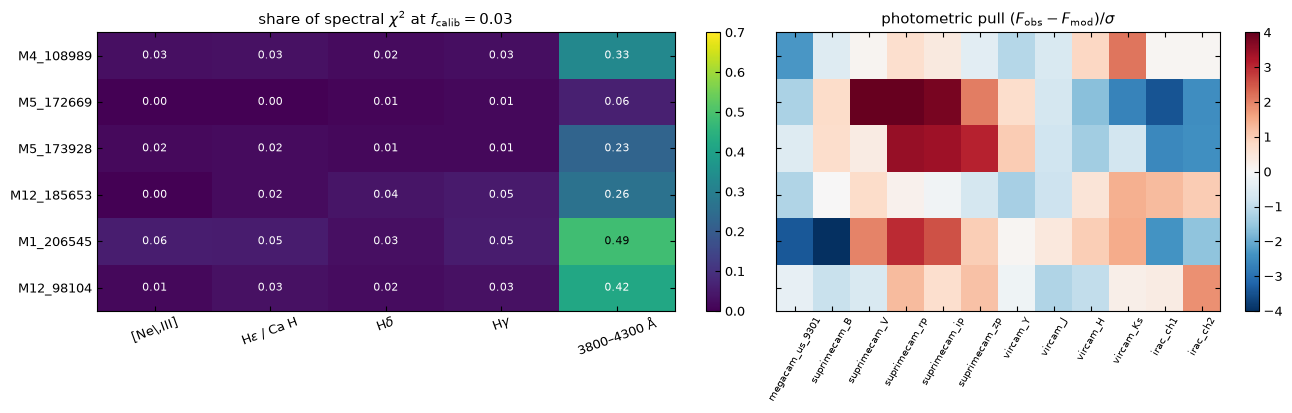

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.3, 1]})
cols = list(LINE_WINDOWS) + ["blue 3800-4300"]
share = chi2_table[cols].to_numpy()
im = axes[0].imshow(share, aspect="auto", cmap="viridis", vmin=0, vmax=max(0.7, share.max()))
axes[0].set_xticks(range(len(cols)))
axes[0].set_xticklabels([r"[Ne\,III]", r"H$\epsilon$ / Ca H", r"H$\delta$", r"H$\gamma$", r"$3800$–$4300$ Å"], rotation=20)
axes[0].set_yticks(range(len(TARGETS))); axes[0].set_yticklabels(TARGETS)
for i in range(share.shape[0]):
    for j in range(share.shape[1]):
        axes[0].text(j, i, f"{share[i, j]:.2f}", ha="center", va="center", color="w" if share[i, j] < 0.45 else "k", fontsize=8)
axes[0].set_title(r"share of spectral $\chi^2$ at $f_{\rm calib}=0.03$")
fig.colorbar(im, ax=axes[0], fraction=0.03)
bands = pull_table.columns
im2 = axes[1].imshow(pull_table.to_numpy(), aspect="auto", cmap="RdBu_r", vmin=-4, vmax=4)
axes[1].set_xticks(range(len(bands))); axes[1].set_xticklabels(bands, rotation=60, fontsize=7)
axes[1].set_yticks(range(len(TARGETS))); axes[1].set_yticklabels([])
axes[1].set_title(r"photometric pull $(F_{\rm obs}-F_{\rm mod})/\sigma$")
fig.colorbar(im2, ax=axes[1], fraction=0.03)
plt.tight_layout(); fig.savefig(OUT / "stage0_chi2_map.png", dpi=130); plt.show()

## 2. Prior rails

- Posterior mass within 5% of the prior range from either edge, per free parameter.
- `spectrum_scaling` uses the ClippedNormal clip limits as its edges.

In [6]:
def prior_edges(g, name):
    text = g.prior_text[name]
    if text.startswith("{"):
        p = json.loads(text); return float(p["low"]), float(p["high"])
    import re
    m = re.search(r"low=([-\d.e]+), high=([-\d.e]+)", text)
    return float(m.group(1)), float(m.group(2))

FRACTION = 0.05
rail_rows = {}
for t, g in galaxies.items():
    w = pgd.posterior_weights(g)
    row = {}
    for name in g.theta_init:
        lo, hi = prior_edges(g, name)
        band = FRACTION * (hi - lo)
        s = g.samples[name]
        s = s if s.ndim == 2 else s[:, None]
        for j in range(s.shape[1]):
            label = name if s.shape[1] == 1 else f"{name}[{j}]"
            row[f"{label} low"] = float(w[s[:, j] <= lo + band].sum())
            row[f"{label} high"] = float(w[s[:, j] >= hi - band].sum())
    rail_rows[t] = row
rails = pd.DataFrame(rail_rows).T
rails.loc[:, (rails > 0.1).any(axis=0)]

,afe low,log_f_calib high,logsfr_ratios[0] high,logsfr_ratios[1] high,logsfr_ratios[3] low,logsfr_ratios[4] low,logsfr_ratios[5] low,logsfr_ratios[5] high,logsfr_ratios[6] high
M4_108989,9.963e-01,1.683e-251,0.069,0.071,0.077,2.181e-01,2.851e-02,3.170e-36,0.143
M5_172669,2.767e-18,0.000e+00,0.059,0.081,0.293,3.003e-137,5.741e-39,1.470e-01,0.055
M5_173928,2.605e-01,7.236e-01,0.004,0.170,0.009,9.897e-02,2.608e-01,2.313e-60,0.118
M12_185653,6.140e-34,2.285e-90,0.041,0.030,0.033,1.364e-01,4.152e-02,6.259e-03,0.106
M1_206545,9.995e-01,4.700e-305,0.304,0.116,0.067,1.608e-01,4.087e-01,1.306e-110,0.151
M12_98104,3.845e-10,1.000e+00,0.037,0.051,0.048,1.261e-01,6.926e-02,8.326e-03,0.081


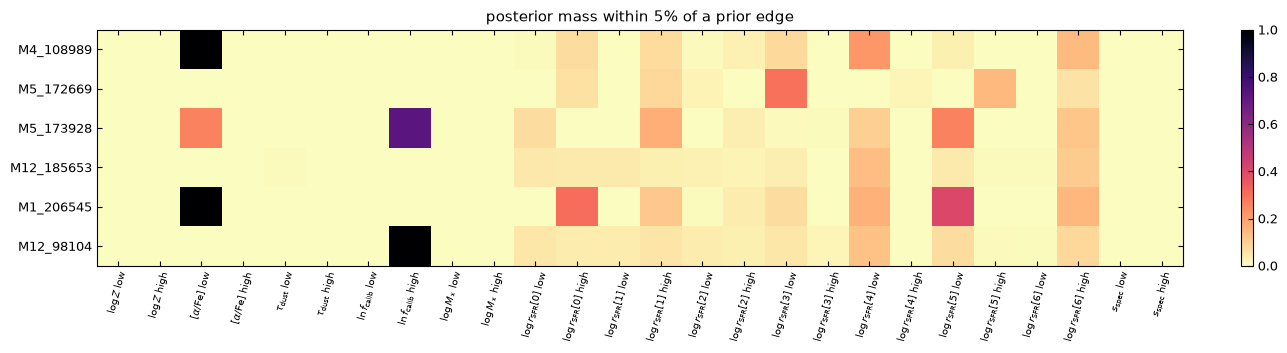

In [7]:
fig, ax = plt.subplots(figsize=(13, 3.6))
data = rails.to_numpy()
im = ax.imshow(data, aspect="auto", cmap="magma_r", vmin=0, vmax=1)
labels = [c.replace("logsfr_ratios", r"$\log r_{\rm SFR}$").replace("log_f_calib", r"$\ln f_{\rm calib}$")
           .replace("diffuse_tau_kc", r"$\tau_{\rm dust}$").replace("afe", r"[$\alpha$/Fe]").replace("logmass", r"$\log M_*$")
           .replace("spectrum_scaling", r"$s_{\rm spec}$").replace("Z", r"$\log Z$") for c in rails.columns]
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=75, fontsize=7)
ax.set_yticks(range(len(TARGETS))); ax.set_yticklabels(TARGETS)
ax.set_title("posterior mass within 5% of a prior edge")
fig.colorbar(im, ax=ax, fraction=0.02)
plt.tight_layout(); fig.savefig(OUT / "stage0_prior_rails.png", dpi=130); plt.show()

## 3. Lick-index recovery against the DR2 catalogue

- 200 weighted posterior draws through `StellarIndices` at the catalogue sigma_star and instrument resolution.
- Catalogue indices come from the uncalibrated DR2 spectrum; model indices are pre-polynomial. Equivalent widths are insensitive; Dn4000 shifts by ~2% under a 25% tilt.
- Catalogue value 0.000 with NaN error is a missing measurement.
- `Hd_flux`, `Hg_flux`, `Hb_flux` are catalogue emission-line fluxes: infill evidence for the masked-line question.

In [8]:
cat = Table.read(PROJECT_ROOT / "data/raw/legac_dr2/legaCdr2.fits.gz").to_pandas()
cat["SPECT_ID"] = cat["SPECT_ID"].astype(str).str.strip()
cat = cat.set_index("SPECT_ID").loc[TARGETS]
INDEX_MAP = {"CN1": "LICK_CN1", "CN2": "LICK_CN2", "Ca4227": "LICK_CA4227", "G4300": "LICK_G4300", "Fe4383": "LICK_FE4383",
             "Ca4455": "LICK_CA4455", "Fe4531": "LICK_FE4531", "C4668": "LICK_C4668", "Hbeta": "LICK_HB", "HdA": "LICK_HD_A",
             "HgA": "LICK_HG_A", "HdF": "LICK_HD_F", "HgF": "LICK_HG_F", "Dn4000": "LICK_D4000_N"}
N_DRAWS = 200
rng = np.random.default_rng(20260906)
lick_rows = []
for t, g in galaxies.items():
    model, _, indices_obs = models[t]
    w = pgd.posterior_weights(g)
    draws = rng.choice(len(w), size=N_DRAWS, replace=True, p=w)
    predict = jax.jit(lambda th: model.predict(th)["stellar_indices"])
    vals = np.array([np.asarray(predict(pgd.theta_at(g, j))) for j in draws])
    q16, q50, q84 = np.percentile(vals, [16, 50, 84], axis=0)
    for k, name in enumerate(indices_obs.index_names):
        col = INDEX_MAP[name]
        obs, err = float(cat.loc[t, col]), float(cat.loc[t, col + "_err"])
        if not np.isfinite(err) or err <= 0:
            obs = np.nan
        sig_model = 0.5 * (q84[k] - q16[k])
        lick_rows.append({"target": t, "index": name, "catalogue": obs, "cat err": err, "model q50": q50[k],
                          "model half-width": sig_model, "resid / cat err": (q50[k] - obs) / err,
                          "resid / total err": (q50[k] - obs) / np.hypot(err, sig_model)})
lick = pd.DataFrame(lick_rows)
lick_wide = lick.pivot(index="target", columns="index", values="resid / total err")[list(INDEX_MAP)]
lick_wide

index,CN1,CN2,Ca4227,G4300,Fe4383,Ca4455,Fe4531,C4668,Hbeta,HdA,HgA,HdF,HgF,Dn4000
target,,,,,,,,,,,,,,
M12_185653,NaN,NaN,2.589,-0.224,-1.993,-0.397,-0.031,-2.752,-2.786,NaN,0.772,NaN,-0.181,NaN
M12_98104,-1.231,-1.999,-1.931,-2.430,NaN,NaN,NaN,NaN,NaN,-0.785,0.802,-1.694,1.106,-0.387
M1_206545,0.093,0.577,-3.022,3.307,-2.227,-0.916,1.940,-5.778,2.824,-1.714,4.373,0.224,1.692,-2.611
M4_108989,-5.356,-5.124,-2.320,1.384,-1.872,0.562,-1.131,-7.469,NaN,2.623,0.365,-0.471,1.324,-2.816
M5_172669,NaN,NaN,-0.568,-0.912,1.447,-2.056,1.754,NaN,2.435,NaN,-0.782,NaN,1.000,NaN
M5_173928,-2.380,-1.668,-0.071,1.479,-3.653,NaN,NaN,NaN,NaN,1.121,1.110,1.402,0.259,-5.523


In [9]:
lick[lick["index"].isin(["HdA", "HdF", "Fe4383", "Dn4000", "Hbeta", "G4300"])].set_index(["target", "index"])

catalogue  cat err  model q50  model half-width  resid / cat err  resid / total err
target     index                                                                                      
M4_108989  G4300       4.643    0.436      5.252             0.060            1.397              1.384
           Fe4383      4.404    0.559      3.355             0.033           -1.875             -1.872
           Hbeta         NaN      NaN      2.073             0.051              NaN                NaN
           HdA        -1.567    0.309     -0.714             0.102            2.761              2.623
           HdF         0.858    0.192      0.762             0.067           -0.499             -0.471
           Dn4000      1.781    0.015      1.733             0.007           -3.128             -2.816
M5_172669  G4300       1.878    0.100      1.781             0.038           -0.977             -0.912
           Fe4383      1.835    0.118      2.013             0.034            1.507              1.447
           Hbeta       3.927    0.090      4.167             0.040            2.669              2.435
           HdA           NaN      NaN      4.633             0.053              NaN                NaN
           HdF           NaN      NaN      3.966             0.034              NaN                NaN
           Dn4000        NaN      NaN      1.425             0.007              NaN                NaN
M5_173928  G4300       3.083    0.611      3.992             0.059            1.486              1.479
           Fe4383      5.171    0.663      2.745             0.042           -3.660             -3.653
           Hbeta         NaN      NaN      2.432             0.024              NaN                NaN
           HdA         0.506    0.377      0.936             0.067            1.138              1.121
           HdF         1.354    0.286      1.760             0.042            1.417              1.402
           Dn4000      1.633    0.022      1.505             0.006           -5.749             -5.523
M12_185653 G4300       5.064    0.459      4.957             0.130           -0.233             -0.224
           Fe4383      4.812    0.721      3.366             0.081           -2.006             -1.993
           Hbeta       3.082    0.295      2.194             0.121           -3.011             -2.786
           HdA           NaN      NaN      0.342             0.217              NaN                NaN
           HdF           NaN      NaN      1.561             0.154              NaN                NaN
           Dn4000        NaN      NaN      1.705             0.011              NaN                NaN
M1_206545  G4300       4.471    0.266      5.358             0.037            3.338              3.307
           Fe4383      4.864    0.436      3.887             0.050           -2.241             -2.227
           Hbeta       0.991    0.355      1.995             0.008            2.824              2.824
           HdA        -0.566    0.212     -0.939             0.051           -1.762             -1.714
           HdF         0.746    0.152      0.780             0.023            0.227              0.224
           Dn4000      1.719    0.014      1.677             0.007           -2.894             -2.611
M12_98104  G4300       5.851    0.832      3.806             0.130           -2.459             -2.430
           Fe4383        NaN      NaN      2.192             0.140              NaN                NaN
           Hbeta         NaN      NaN      2.528             0.097              NaN                NaN
           HdA         2.200    0.628      1.666             0.261           -0.851             -0.785
           HdF         2.866    0.426      2.089             0.168           -1.821             -1.694
           Dn4000      1.559    0.039      1.542             0.017           -0.420             -0.387

In [10]:
emission = cat[["Hd_flux", "Hd_err", "Hg_flux", "Hg_err", "Hb_flux", "Hb_err", "OII_3727_flux", "OII_3727_err"]].copy()
for line in ("Hd", "Hg", "Hb", "OII_3727"):
    emission[f"{line} S/N"] = emission[f"{line}_flux"] / emission[f"{line}_err"]
emission[[c for c in emission.columns if "S/N" in c]]

,Hd S/N,Hg S/N,Hb S/N,OII_3727 S/N
SPECT_ID,,,,
M4_108989,NaN,NaN,NaN,NaN
M5_172669,NaN,NaN,NaN,NaN
M5_173928,NaN,NaN,NaN,NaN
M12_185653,NaN,NaN,NaN,NaN
M1_206545,NaN,NaN,NaN,NaN
M12_98104,0.0,NaN,NaN,1.762


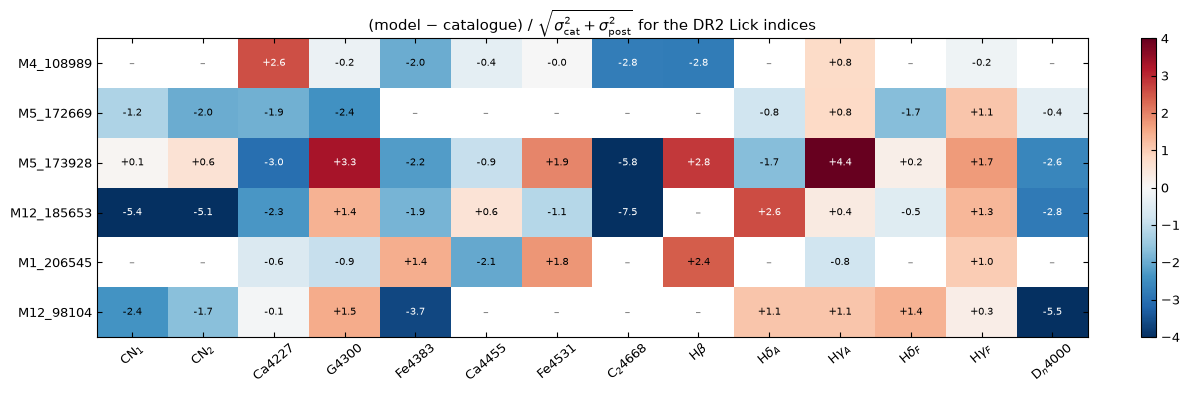

In [11]:
LABELS = {"CN1": r"CN$_1$", "CN2": r"CN$_2$", "Ca4227": "Ca4227", "G4300": "G4300", "Fe4383": "Fe4383", "Ca4455": "Ca4455",
          "Fe4531": "Fe4531", "C4668": r"C$_2$4668", "Hbeta": r"H$\beta$", "HdA": r"H$\delta_A$", "HgA": r"H$\gamma_A$",
          "HdF": r"H$\delta_F$", "HgF": r"H$\gamma_F$", "Dn4000": r"D$_n$4000"}
fig, ax = plt.subplots(figsize=(12, 4))
data = lick_wide.to_numpy()
im = ax.imshow(data, aspect="auto", cmap="RdBu_r", vmin=-4, vmax=4)
ax.set_xticks(range(len(INDEX_MAP))); ax.set_xticklabels([LABELS[k] for k in INDEX_MAP], rotation=40)
ax.set_yticks(range(len(TARGETS))); ax.set_yticklabels(TARGETS)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        if np.isfinite(data[i, j]):
            ax.text(j, i, f"{data[i, j]:+.1f}", ha="center", va="center", fontsize=7, color="k" if abs(data[i, j]) < 2.5 else "w")
        else:
            ax.text(j, i, "–", ha="center", va="center", fontsize=8, color="0.5")
ax.set_title(r"(model $-$ catalogue) / $\sqrt{\sigma_{\rm cat}^2+\sigma_{\rm post}^2}$ for the DR2 Lick indices")
fig.colorbar(im, ax=ax, fraction=0.02)
plt.tight_layout(); fig.savefig(OUT / "stage0_lick_residuals.png", dpi=130); plt.show()

## 4. Borghi+22 overlap

- Two of the six targets are in Borghi+22; ages there are SSP-equivalent (light-weighted), ours are mass-weighted draws.
- [Z/H] = log10 Z - log10 Z_sun with Z_sun = 0.0142 (MIST).

In [12]:
LOG_ZSUN = np.log10(0.0142)
borghi = pd.concat([pd.read_csv(p, sep="\t", comment="#") for p in
                    (PROJECT_ROOT / "data/processed/borghi2022_legac_dr2").glob("*_spectrum_matches.tsv")])
borghi = borghi.set_index("dr2_spect_id")
brows = []
for t, g in galaxies.items():
    if t not in borghi.index:
        continue
    b = borghi.loc[t]
    w = pgd.posterior_weights(g)
    q = lambda x: [pgd.weighted_quantile(x, w, p) for p in (0.16, 0.5, 0.84)]
    zh = q(g.samples["Z"] - LOG_ZSUN); afe = q(g.samples["afe"])
    age = np.percentile(g.mass_weighted_age_draws, [16, 50, 84])
    brows.append({"target": t,
                  "age MW q50 [Gyr]": age[1], "age MW q16": age[0], "age MW q84": age[2],
                  "Borghi age [Gyr]": b["borghi_age_gyr"], "Borghi age -/+": (b["borghi_age_err_lower_gyr"], b["borghi_age_err_upper_gyr"]),
                  "[Z/H] q50": zh[1], "[Z/H] q16": zh[0], "[Z/H] q84": zh[2],
                  "Borghi [Z/H]": b["borghi_z_over_h_dex"], "Borghi [Z/H] err": b["borghi_z_over_h_err_upper_dex"],
                  "[a/Fe] q50": afe[1], "[a/Fe] q16": afe[0], "[a/Fe] q84": afe[2],
                  "Borghi [a/Fe]": b["borghi_alpha_over_fe_dex"], "Borghi [a/Fe] err": b["borghi_alpha_over_fe_err_upper_dex"]})
borghi_table = pd.DataFrame(brows).set_index("target")
borghi_table.T

target,M4_108989,M12_185653
age MW q50 [Gyr],4.61,5.017
age MW q16,4.505,4.465
age MW q84,4.736,5.206
Borghi age [Gyr],4.028,3.109
Borghi age -/+,"(0.563, 0.642)","(0.297, 0.52)"
[Z/H] q50,-0.03,-0.34
[Z/H] q16,-0.061,-0.399
[Z/H] q84,-0.0,-0.242
Borghi [Z/H],0.067,-0.014
Borghi [Z/H] err,0.066,0.043


## Summary table

- One row per galaxy; the columns each stage-1 arm is scored against.

In [13]:
summary = chi2_table.copy()
summary["railed params"] = [", ".join(c.rsplit(" ", 1)[0] for c in rails.columns if rails.loc[t, c] > 0.5) for t in TARGETS]
for name in ("HdA", "Fe4383", "Dn4000", "Hbeta"):
    summary[f"{name} resid/err"] = lick_wide[name]
summary.to_csv(OUT / "stage0_summary.csv")
summary.T

target,M4_108989,M5_172669,M5_173928,M12_185653,M1_206545,M12_98104
f_calib fit,0.044,0.027,0.09,0.063,0.039,0.1
chi2/nu fitted f,1.146,1.042,0.958,1.116,1.319,1.552
chi2/nu f=0.03,1.5,0.863,2.607,2.003,1.585,2.167
chi2 spec f=0.03,5604.248,3110.095,10000.053,7163.604,5425.362,8244.769
|pull|>4 (f=0.03),12,18,77,24,19,32
chi2 phot,13.449,99.936,50.953,9.771,62.514,10.634
IRAC share of phot chi2,0.001,0.181,0.249,0.266,0.133,0.321
[NeIII] 3869,0.028,0.0,0.017,0.0,0.055,0.015
Hepsilon 3970,0.033,0.0,0.02,0.022,0.054,0.032
Hdelta 4102,0.022,0.009,0.015,0.039,0.028,0.024


## Reading

- Blue window share vs pixel share says whether the Balmer/CN region is over-represented in chi2.
- IRAC share ranks `no_irac`; f_calib rails rank `floor20`; SFR-ratio rails rank `sfh_cont`.
- Lick residuals with a common sign across galaxies point at the model family, not at noise.